# Ensemble Learning Methods

---

## What is Ensemble Learning?

**Ensemble Learning** combines **multiple models (called base/weak learners)** to produce a **stronger, more accurate model**.

Think of it like a **team of doctors** diagnosing a patient — consulting multiple doctors and taking a majority vote gives a better diagnosis than relying on one doctor alone.

---

## Methods Covered

| Method | Category | Core Idea |
|---|---|---|
| **Voting Classifier** | Combining | Vote among independent models |
| **AdaBoost** | Boosting | Sequentially correct mistakes |
| **Gradient Boosting** | Boosting | Minimize residual errors iteratively |


---
##  Step 1: Import All Required Libraries

| Library | Purpose |
|---|---|
| `sklearn.ensemble` | VotingClassifier, AdaBoost, GradientBoosting |
| `sklearn.linear_model` | Logistic Regression |
| `sklearn.tree` | Decision Tree + tree visualization |
| `sklearn.svm` | Support Vector Machine |
| `sklearn.datasets` | Built-in datasets (Iris) |
| `sklearn.model_selection` | Train-test split utility |
| `matplotlib.pyplot` | Plotting and visualization |


In [21]:
# ── Ensemble Models ───────────────────────────────────────────────
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# ── Base / Weak Learners ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# ── Dataset & Utilities ───────────────────────────────────────────
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

print('All libraries imported successfully!')


All libraries imported successfully!


---
## Step 2: Load and Prepare the Iris Dataset

### About the Iris Dataset
- **150 samples** of iris flowers
- **4 features**: sepal length, sepal width, petal length, petal width (cm)
- **3 classes**: Setosa, Versicolor, Virginica
- **Goal**: Classify which species a flower belongs to

### Train-Test Split
- **75% → Training set** — model learns from this
- **25% → Testing set** — model is evaluated on unseen data
- `random_state=42` ensures the **same split every run** (reproducibility)


In [22]:
# Load the Iris dataset
iris = load_iris()

# X = features (input),  y = labels (target/output)

X, y = load_iris(return_X_y=True)

# Split: 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,   # 25% held out for testing
    random_state=42   # Fixed seed for reproducibility
)

print(' Dataset Summary')
print(f'  Total samples    : {len(X)}')
print(f'  Training samples : {len(X_train)}')
print(f'  Testing samples  : {len(X_test)}')
print(f'  Features         : {iris.feature_names}')
print(f'  Classes          : {list(iris.target_names)}')


 Dataset Summary
  Total samples    : 150
  Training samples : 112
  Testing samples  : 38
  Features         : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Classes          : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


---
##  Part A: Voting Classifier

### How It Works
Trains **multiple independent models** and combines predictions:
```
      Input Data
          │
   ┌──────┼──────┐
   ▼      ▼      ▼
  [LR]  [DT]  [SVC]
   │      │      │
   └──────┼──────┘
          │
      COMBINE
  (Vote / Average)
          │
   Final Prediction
```

### Hard vs Soft Voting
| Type | How It Works |
|---|---|
| **Hard Voting** | Each model casts 1 vote → majority class wins |
| **Soft Voting** | Average predicted probabilities → highest avg wins |

**Example (Hard):** LR→Class1, DT→Class0, SVC→Class1 → **Final = Class 1** (2/3 votes)

**Example (Soft):** Average probabilities [0.15, 0.63, 0.22] → **Final = Class 1** (highest avg)


In [23]:
#implement Voting Ensemble
# ── Step A1: Define Three Base Models ────────────────────────────

lr  = LogisticRegression(max_iter=200)  # max_iter=200: allow enough iterations
dt  = DecisionTreeClassifier()          # Default: grows a full tree
svc = SVC(probability=True)             # probability=True is REQUIRED for soft voting

# NOTE: By default SVC does NOT output class probabilities.
# We MUST set probability=True for soft voting to work.

print(' Three base models defined:')
print('   → Logistic Regression (lr)')
print('   → Decision Tree       (dt)')
print('   → Support Vector Clf  (svc) [with probability=True]')


 Three base models defined:
   → Logistic Regression (lr)
   → Decision Tree       (dt)
   → Support Vector Clf  (svc) [with probability=True]


In [25]:
# ── Step A2: Create the Voting Ensemble ──────────────────────────

voting_clf = VotingClassifier(
    estimators=[
        ('lr',  lr),    # tuple format: ('label', model_object)
        ('dt',  dt),
        ('svc', svc)
    ],
    voting='soft'   # 'soft' (probabilities) or 'hard' (majority vote)
)

# 'estimators': list of (name, model) pairs
#               names are used for identifying models internally
# 'voting'    : strategy for combining predictions

print('VotingClassifier created with SOFT voting.')
voting_clf


VotingClassifier created with SOFT voting.


VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=200)),
                             ('dt', DecisionTreeClassifier()),
                             ('svc', SVC(probability=True))],
                 voting='soft')

In [9]:
# ── Step A3: Train, Evaluate, and Compare ────────────────────────

# fit() trains ALL three base models internally on X_train
voting_clf.fit(X_train, y_train)
voting_accuracy = voting_clf.score(X_test, y_test)

print(f' Voting Classifier Accuracy : {voting_accuracy * 100:.2f}%')
lr.fit(X_train,y_train)
lr_score=lr.score(X_test,y_test)
print(lr_score)
dt.fit(X_train,y_train)
dt_score=lr.score(X_test,y_test)
print(dt_score)
svc.fit(X_train,y_train)
svc_score=lr.score(X_test,y_test)
print(svc_score)
# Compare against individual models
print('\nIndividual Model Accuracies (for comparison):')
for name, model in [('Logistic Regression', lr), ('Decision Tree', dt), ('SVC', svc)]:
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f'   {name:<22}: {acc * 100:.2f}%')


 Voting Classifier Accuracy : 100.00%

Individual Model Accuracies (for comparison):
   Logistic Regression   : 100.00%
   Decision Tree         : 100.00%
   SVC                   : 100.00%


---
## Part B: AdaBoost (Adaptive Boosting)

### How It Works (Sequential Learning)
```
Round 1: Train Stump 1  →  note mistakes
         ↓  increase weight of misclassified samples
Round 2: Train Stump 2  →  focuses harder on round 1 mistakes
         ↓  increase weight again
Round 3: Train Stump 3  →  ...
         ↓
Final = Weighted combination of all 50 stumps
```

### Key Terms
| Term | Meaning |
|---|---|
| **Weak Learner** | A model slightly better than random guessing |
| **Decision Stump** | Decision Tree with `max_depth=1` (only 1 split) |
| **n_estimators** | Number of boosting rounds / weak learners |
| **learning_rate** | How much each learner contributes to the final result |

### Why Stumps?
A stump asks one question about one feature. It is **intentionally weak** — but 50 stumps working together can be very powerful.


In [10]:
# ── Step B1: Define the Weak Learner (Decision Stump) ────────────

stump = DecisionTreeClassifier(max_depth=1)

# max_depth=1 means the tree:
#   - Asks exactly ONE question (splits on ONE feature)
#   - Has TWO leaf nodes (two predictions)
#   - Is intentionally very simple / weak

print(' Weak learner (Decision Stump with max_depth=1) defined.')
print('   A stump makes just ONE decision about the data.')


 Weak learner (Decision Stump with max_depth=1) defined.
   A stump makes just ONE decision about the data.


In [26]:
# ── Step B2: Build the AdaBoost Classifier ───────────────────────

adaboost = AdaBoostClassifier(
    estimator=stump,     # Weak learner to use (our decision stump)
    n_estimators=50,     # Train 50 stumps sequentially
    learning_rate=1.0,   # Each stump contributes fully (1.0 = 100%)
    random_state=42      # Reproducibility
)
adaboost

# Important: parameter is 'estimator' (NOT 'base_estimator')
#     'base_estimator' was renamed to 'estimator' in sklearn v1.2+

print(' AdaBoostClassifier built:')
print('   → estimator    : Decision Stump (max_depth=1)')
print('   → n_estimators : 50 rounds of boosting')
print('   → learning_rate: 1.0')


 AdaBoostClassifier built:
   → estimator    : Decision Stump (max_depth=1)
   → n_estimators : 50 rounds of boosting
   → learning_rate: 1.0


In [12]:
# ── Step B3: Train and Evaluate AdaBoost ─────────────────────────

adaboost.fit(X_train, y_train)

ada_accuracy = adaboost.score(X_test, y_test)
print(f'AdaBoost Accuracy: {ada_accuracy * 100:.2f}%')
print(f'   Total stumps trained: {len(adaboost.estimators_)}')


AdaBoost Accuracy: 94.74%
   Total stumps trained: 50


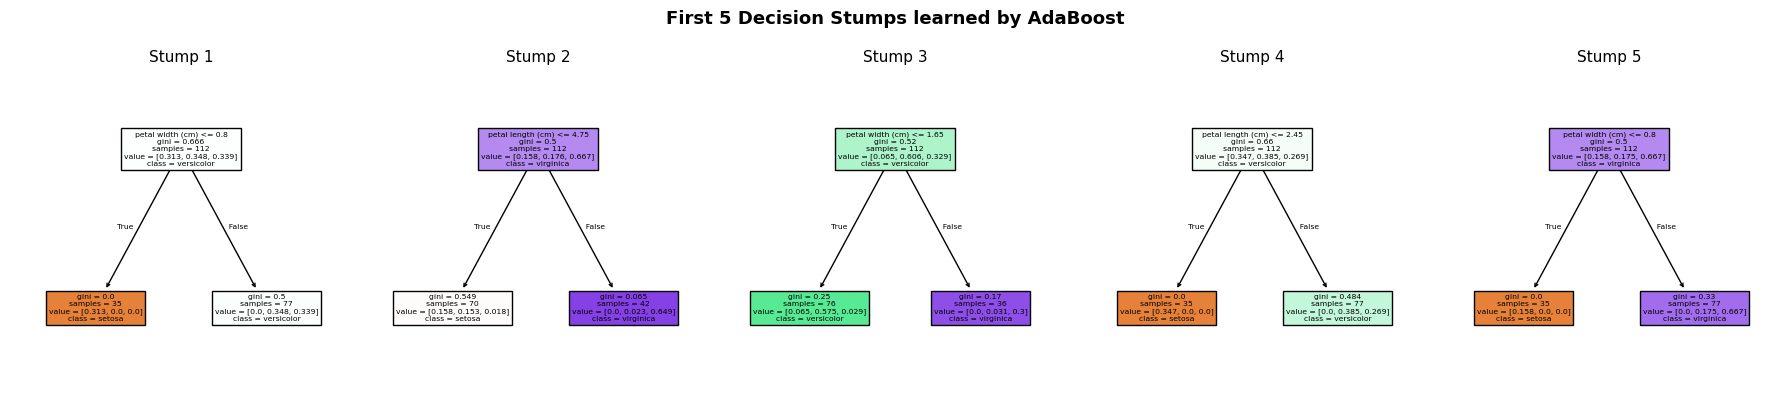


 Each stump splits on a DIFFERENT feature/threshold.
   AdaBoost re-weights samples so each new stump learns from past mistakes.


In [13]:
# ── Step B4: Visualize the First 5 Stumps ────────────────────────
#
# adaboost.estimators_ → list of all 50 trained stumps
# We plot first 5 to see how each stump looks different

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 4))
fig.suptitle('First 5 Decision Stumps learned by AdaBoost',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes):
    clf = adaboost.estimators_[i]          # i-th trained stump
    if isinstance(clf, DecisionTreeClassifier):
        plot_tree(
            clf,
            filled=True,                       # Color nodes by majority class
            feature_names=iris.feature_names,  # Show feature names
            class_names=iris.target_names,     # Show class names
            ax=ax
        )
        ax.set_title(f'Stump {i + 1}', fontsize=11)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

print('\n Each stump splits on a DIFFERENT feature/threshold.')
print('   AdaBoost re-weights samples so each new stump learns from past mistakes.')


---
## Part C: Gradient Boosting

### How It Works
Instead of reweighting samples (AdaBoost), Gradient Boosting trains each new tree to **predict the residual errors** of the current ensemble:
```
Tree 1 predicts        → error₁ = actual − predicted₁
Tree 2 predicts error₁ → error₂ = error₁ − predicted₂
Tree 3 predicts error₂ → ...
Final = Tree1 + lr×Tree2 + lr×Tree3 + ...
```

### Key Parameters
| Parameter | Meaning | Rule of Thumb |
|---|---|---|
| `n_estimators` | Number of trees | More trees = more complex |
| `learning_rate` | Step size per tree | Smaller → more careful, needs more trees |
| `max_depth` | Depth of each tree | Shallower (3-5) is usually best |

### AdaBoost vs Gradient Boosting
| Feature | AdaBoost | Gradient Boosting |
|---|---|---|
| Correction method | Re-weight samples | Predict residual errors |
| Base learner | Stumps (depth=1) | Shallow trees (depth 3-5) |
| Modern variants | — | XGBoost, LightGBM, CatBoost |


In [14]:
# ── Step C1: Build the Gradient Boosting Classifier ──────────────

gb = GradientBoostingClassifier(
    n_estimators=100,   # Build 100 sequential decision trees
    learning_rate=0.1,  # Each tree contributes 10% toward the prediction
    max_depth=3         # Shallow trees work better for boosting
)
gb
# Common tradeoff:
#   Many trees + small learning_rate  → better accuracy, slower training
#   Few trees  + large learning_rate  → fast training, risk of overfitting

print(' GradientBoostingClassifier built:')
print('   → n_estimators : 100 trees')
print('   → learning_rate: 0.1  (each tree contributes 10%)')
print('   → max_depth    : 3 levels per tree')


 GradientBoostingClassifier built:
   → n_estimators : 100 trees
   → learning_rate: 0.1  (each tree contributes 10%)
   → max_depth    : 3 levels per tree


In [18]:
# ── Step C2: Train and Evaluate ──────────────────────────────────

gb.fit(X_train, y_train)

gb_accuracy = gb.score(X_test, y_test)
print(f'Gradient Boosting Accuracy: {gb_accuracy * 100:.2f}%')


Gradient Boosting Accuracy: 100.00%


---
##  Final Comparison: All Methods Side by Side


In [20]:
# ── Final Summary: Compare all models ────────────────────────────

results = {
    'Logistic Regression\n(single model)': lr.score(X_test, y_test),
    'Decision Tree\n(single model)'      : dt.score(X_test, y_test),
    'SVC\n(single model)'                : svc.score(X_test, y_test),
    'Voting Classifier\n(ensemble)'      : voting_accuracy,
    'AdaBoost\n(ensemble)'               : ada_accuracy,
    'Gradient Boosting\n(ensemble)'      : gb_accuracy,
}

# ── Print table ──────────────────────────────────────────────────
print('=' * 52)
print(f'{"Model":<38} {"Accuracy":>8}')
print('=' * 52)
for name, acc in results.items():
    print(f'{name.replace(chr(10), " "):<38} {acc*100:>6.2f}%')
print('=' * 52)



Model                                  Accuracy
Logistic Regression (single model)     100.00%
Decision Tree (single model)           100.00%
SVC (single model)                     100.00%
Voting Classifier (ensemble)           100.00%
AdaBoost (ensemble)                     94.74%
Gradient Boosting (ensemble)           100.00%


---
##  Summary 


| Concept | One-line Summary |
|---|---|
| **Ensemble Learning** | Combine multiple models for better performance |
| **Voting Classifier** | Independent models vote; majority/average wins |
| **Hard Voting** | Count class votes across all models |
| **Soft Voting** | Average class probabilities (usually better) |
| **AdaBoost** | Sequential; each model focuses on previous mistakes |
| **Decision Stump** | Very shallow tree (depth=1) used as a weak learner |
| **Gradient Boosting** | Sequential; each model predicts residual errors |
| **learning_rate** | Controls how aggressively each tree updates predictions |

### When to Use What?
- **Voting Classifier** → You already have trained models; quick accuracy boost
- **AdaBoost** → Smaller datasets; good interpretability with stumps
- **Gradient Boosting / XGBoost** → Competitions, structured data, max accuracy

---

###  Exam Tip
> *"Ensemble methods follow the wisdom-of-crowds principle: many weak learners together form one strong learner."*

This idea is formalized in statistics as the **Condorcet Jury Theorem**.


In [ ]:
# ── Bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#a8c8e8', '#a8c8e8', '#a8c8e8',
          '#2ecc71', '#e67e22', '#9b59b6']

bars = ax.bar(
    list(results.keys()),
    [v * 100 for v in results.values()],
    color=colors, edgecolor='black', linewidth=0.8
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylim(85, 103)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Ensemble vs Individual Model Accuracy — Iris Dataset',
             fontsize=13, fontweight='bold')
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% line')
ax.legend(fontsize=10)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()
